# UQ Benchmarking: Quantitative Evaluation on Real Medical QA

This notebook is the quantitative companion to **`UQ_Tutorial.ipynb`**. Where that notebook shows *how* each uncertainty quantification (UQ) technique works on individual examples, this one answers a different question:

> **"How well does each UQ technique predict when the model will make a clinical error?"**

We are not evaluating the LLM's accuracy -- we are evaluating how *informative* its uncertainty scores are: do high-uncertainty predictions correspond to wrong answers more often than low-uncertainty ones?

**Dataset:** MedQA-USMLE + MMLU-Medical (clinical multiple-choice) &nbsp;|&nbsp; **Model:** `Qwen/Qwen3-0.6B` (local, white-box) &nbsp;|&nbsp; **Libraries:** lm-polygraph, UQLM &nbsp;|&nbsp; **Primary metric:** PRR (Prediction-Rejection Ratio), as recommended by the TACL paper and the AAAI-2026 tutorial.

| Metric | Range | Direction | What it measures |
|---|---|---|---|
| **PRR** (Prediction-Rejection Ratio) | [-1, 1] (0 = random) | ↑ higher = better | How much accuracy improves when uncertain predictions are filtered out (primary) |
| **AUROC** | [0, 1] (0.5 = random) | ↑ higher = better | How well the uncertainty score distinguishes correct from incorrect answers |
| **AUARC** | [0, 1] | ↑ higher = better | Area under the accuracy-rejection curve (unnormalized PRR) |
| **Acc@50%** | [0%, 100%] | ↑ higher = better | Accuracy when rejecting the 50% most uncertain predictions |

Built on the same shared **`uq_toolbox`** package as `UQ_Tutorial.ipynb` -- cloned from the same GitHub repo below, so both notebooks stay in sync.


## 📑 Table of Contents

- [📊1️⃣ Configuration](#configuration) (incl. 🔧 Model Definition)
- [📊2️⃣ Dataset Loading](#dataset-loading)
- [📊3️⃣ Batch Inference & UQ Scoring](#batch-inference-uq-scoring)
- [📊4️⃣ Correctness Analysis](#correctness-analysis)
- [📊5️⃣ Evaluation Metrics](#evaluation-metrics)
- [📊6️⃣ Computing All Metrics](#computing-all-metrics)
- [📊7️⃣ Visualizations](#visualizations)
- [📊8️⃣ Cross-Library Comparison](#cross-library-comparison-lm-polygraph-vs-uqlm)
- [📊 Bonus: UQLM Native Evaluation](#bonus-uqlms-own-native-evaluation-utilities)
- [📊9️⃣ Bootstrap Confidence Intervals](#statistical-analysis-bootstrap-confidence-intervals-for-prr)
- [📊🔟 Calibration Analysis](#calibration-analysis)
- [📊1️⃣1️⃣ Summary & Conclusions](#summary-conclusions)
- [References](#references)

## Prerequisites

- **A Hugging Face account + access token** (`HF_TOKEN`) -- required to download `Qwen/Qwen3-0.6B`.
- **An OpenAI API key** (`OPENAI_API_KEY`) -- used by the LLM-as-judge grader in a couple of UQLM scorers.
- **Expected runtime**: with the default `N_SAMPLES = 24` (a smoke-test size), this runs in a few minutes on a free Colab GPU, or somewhat longer on CPU. Raise `N_SAMPLES` for more statistically reliable PRR estimates.


## ⚙️ Global Setup

Installed and loaded **once**.

> ⚠️ **Restart the runtime immediately after the install cell below finishes** (Runtime → Restart runtime in Colab), *before* running anything else. The install cell upgrades packages (e.g. `transformers`) that Python may have already loaded elsewhere -- restarting ensures the upgraded versions are actually the ones in use.


In [5]:
%pip install -q "pip<24.1"

%pip install -q -U \
  lm-polygraph \
  uqlm \
  langchain-openai \
  langchain-huggingface \
  langchain-anthropic \
  langchain-google-genai \
  langchain-ollama \
  pandas \
  plotly \
  matplotlib \
  seaborn \
  "transformers>=4.51,<5.0" \
  accelerate \
  bitsandbytes \
  sentence-transformers \
  datasets \
  scikit-learn \
  nltk \
  ipywidgets

# Optional: dev-branch lm-polygraph + the supervised uncertainty-head package, needed only by
# Part 2 of UQ_Tutorial.ipynb's "learned uncertainty" subsection. Wrapped so a failure here doesn't block the rest of
# the notebook -- uq_toolbox already falls back gracefully if this isn't installed.
%pip install -q \
  "git+https://github.com/IINemo/lm-polygraph.git@dev" \
  "git+https://github.com/IINemo/llm-uncertainty-head.git" || true

%pip install -q --force-reinstall "protobuf==5.29.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 31.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.7/137.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.9/267.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.0/203.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import os

os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_TORCH"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [2]:
# from getpass import getpass

# if "OPENAI_API_KEY" not in os.environ:
#     os.environ["OPENAI_API_KEY"] = getpass("🔑 Enter your OpenAI API Key: ")
# os.environ["OPENAI_BASE_URL"] = "https://api.openai.com/v1"

# if "HF_TOKEN" not in os.environ:
#     os.environ["HF_TOKEN"] = getpass("🔑 Enter your Hugging Face token: ")


In [3]:
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
os.environ["OPENAI_BASE_URL"] = "https://api.openai.com/v1"
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!rm -rf /content/UQ-Text-Mining
!cp -r "/content/drive/MyDrive/UQ-Text-Mining" /content/UQ-Text-Mining

from pathlib import Path
import sys

REPO_DIR = Path("/content/UQ-Text-Mining")

%pip install -q -e {REPO_DIR}

sys.path.insert(0, str(REPO_DIR / "notebooks"))

import uq_toolbox
from uq_toolbox import evaluate_uncertainty
from uq_toolbox.managers.model_manager import UQModelManager, initialize_uq_models
from uq_toolbox.registry import UQ_REGISTRY, UQLibrary

print("Loaded uq_toolbox from:", uq_toolbox.__file__)
print("Techniques registered — lm-polygraph:", len(UQ_REGISTRY[UQLibrary.POLYGRAPH]),
      "| uqlm:", len(UQ_REGISTRY[UQLibrary.UQLM]))

Mounted at /content/drive
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for uq_toolbox (pyproject.toml) ... done


/content/UQ-Text-Mining/notebooks/uq_toolbox/registry.py:42: SyntaxWarning: invalid escape sequence '\|'
  "description": "Quantifies sequence uncertainty and individual confidence scores by constructing response coordinate embeddings via graph Laplacian eigenvectors. Uncertainty is measured as the norm of the offset from the average embedding ($U_{\text{Ecc}} = \|[v_1'^\top, \dots, v_m'^\top]\|_2$), while confidence corresponds to the negative distance from the center ($C_{\text{Ecc}}(x, s_j) = -\|v_j'\|_2$).[Reference: (Lin et al., 2023, https://arxiv.org/abs/2305.19187]"


Loaded uq_toolbox from: /content/UQ-Text-Mining/notebooks/uq_toolbox/__init__.py
Techniques registered — lm-polygraph: 39 | uqlm: 17


# 📊 Benchmarking


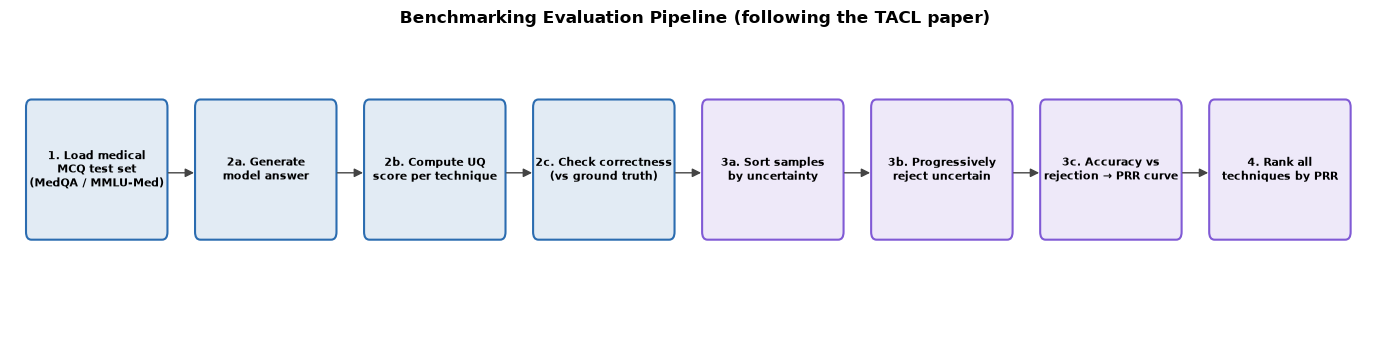

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

steps = [
    "1. Load medical\nMCQ test set\n(MedQA / MMLU-Med)",
    "2a. Generate\nmodel answer",
    "2b. Compute UQ\nscore per technique",
    "2c. Check correctness\n(vs ground truth)",
    "3a. Sort samples\nby uncertainty",
    "3b. Progressively\nreject uncertain",
    "3c. Accuracy vs\nrejection \u2192 PRR curve",
    "4. Rank all\ntechniques by PRR",
]

fig, ax = plt.subplots(figsize=(14, 3.6))
ax.axis("off")
w, h, gap = 1.55, 1.05, 0.35
x = 0.2
for i, s in enumerate(steps):
    color = "#2b6cb0" if i < 4 else "#805ad5"
    ax.add_patch(FancyBboxPatch((x, 0.8), w, h, boxstyle="round,pad=0.02,rounding_size=0.06",
                                 linewidth=1.5, edgecolor=color, facecolor=color + "22"))
    ax.text(x + w/2, 0.8 + h/2, s, ha="center", va="center", fontsize=8, fontweight="bold")
    if i < len(steps) - 1:
        ax.add_patch(FancyArrowPatch((x + w, 1.3), (x + w + gap, 1.3), arrowstyle="-|>", mutation_scale=13, color="#444"))
    x += w + gap

ax.set_xlim(0, x); ax.set_ylim(0, 2.4)
ax.set_title("Benchmarking Evaluation Pipeline (following the TACL paper)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 📊1️⃣ Configuration

All key parameters are in a single cell -- change them here to adapt the benchmark to a different dataset size.

> **Quick start:** `N_SAMPLES = 24` is a fast smoke-test. For paper-faithful results use `N_SAMPLES = 200+`.


### 🔧 Model Definition

Loads the shared backbone once, in white-box mode -- both lm-polygraph's native estimators and UQLM's scorers (via a LangChain-wrapped HuggingFace pipeline over the *same* model instance) run against it.


In [6]:
from pathlib import Path
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.metrics import roc_auc_score
import torch

RANDOM_SEED = 42
BENCH_ALIAS = "qwen"
BENCH_MODEL_ID = "Qwen/Qwen3-0.6B"

uq_engine = initialize_uq_models(
    polygraph_models={
        BENCH_ALIAS: {"model_id": BENCH_MODEL_ID, "mode": "white"},
    },
    p_mode="white",
    temperature=0.7,
    max_tokens=32,
)

# Register a matching UQLM (LangChain) LLM over the *same* HuggingFace model/tokenizer,
# so UQLM scorers reuse the already-loaded weights instead of downloading a second copy.
from transformers import pipeline as _hf_pipeline
from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace
from langchain_core.runnables.config import run_in_executor
from langchain_core.messages import SystemMessage, HumanMessage

class _AsyncCompatibleChatHF(ChatHuggingFace):
    async def _agenerate(self, messages, stop=None, run_manager=None, **kwargs):
        return await run_in_executor(None, self._generate, messages, stop, None, **kwargs)

    def _to_chat_prompt(self, messages):
        if messages and isinstance(messages[0], SystemMessage):
            if len(messages) > 1 and isinstance(messages[1], HumanMessage):
                merged = HumanMessage(f"{messages[0].content}\n\n{messages[1].content}")
                messages = [merged] + messages[2:]
            else:
                messages = messages[1:]
        return super()._to_chat_prompt(messages)

_bm = uq_engine.polygraph_models[BENCH_ALIAS]
_bench_pipe = _hf_pipeline(
    "text-generation", model=_bm.model, tokenizer=_bm.tokenizer,
    max_new_tokens=32, return_full_text=False, do_sample=True, temperature=0.7,
)
uq_engine.add_uqlm_model(
    provider="custom", alias=BENCH_ALIAS, mode="white",
    custom_llm=_AsyncCompatibleChatHF(llm=HuggingFacePipeline(pipeline=_bench_pipe)),
)

N_SAMPLES = 24
DATASETS = {
    "MedQA":        {"hf_path": "GBaker/MedQA-USMLE-4-options",   "split": "test"},
    "MMLU-Medical": {"hf_path": "cais/mmlu", "hf_name": "clinical_knowledge", "split": "test"},
}

# (technique_name, library, granularity, display_label, family) -- clean registry names +
# an explicit library field (no string-prefix routing, per the enum-based registry design).
BENCHMARK_TECHNIQUES = [
    ("LabelProb",                   "lm_polygraph", "sequence", "LabelProb",        "Consistency-BB"),
    ("EigLaplacian",                "lm_polygraph", "sequence", "EigLaplacian",      "Consistency-BB"),
    ("Entailment",                  "uqlm",         "sequence", "UQLM-Entailment",   "Consistency-BB"),
    ("MaximumSequenceProbability",  "lm_polygraph", "sequence", "MSP",               "Info-WB"),
    ("MeanTokenEntropy",            "lm_polygraph", "sequence", "MeanTokenEntropy",  "Info-WB"),
    ("MahalanobisDistanceSeq",      "lm_polygraph", "sequence", "Mahalanobis",       "Introspective-WB"),
]
# NOTE: one representative technique per family (kept both members of the EigLaplacian/
# UQLM-Entailment cross-library pair used in Section 8). A full sweep of every registered
# technique is possible but was measured to take >30min/prompt on CPU -- infeasible for
# N_SAMPLES >= 6 in this environment. This subset covers every family and both libraries.

NUM_SAMPLES_UQ = 3
TEMPERATURE    = 0.7

RESULTS_DIR  = Path("benchmark_results")
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Model: {BENCH_MODEL_ID}  (alias '{BENCH_ALIAS}')")
print(f"Samples per dataset: {N_SAMPLES}")
print(f"Techniques to benchmark: {len(BENCHMARK_TECHNIQUES)}")
for tech, lib, gran, label, family in BENCHMARK_TECHNIQUES:
    print(f"  [{family:<18s}] {label}  ({lib})")



🚀 INITIALIZING MULTI-MODE UQ EXPERIMENTAL ENVIRONMENT

⚙️ Adding lm_polygraph [QWEN] in WHITE-BOX mode...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]


✅ ENVIRONMENT READY FOR QUANTIFICATION PIPELINES

📊 Adding UQLM [QWEN] in WHITE-BOX mode...
Model: Qwen/Qwen3-0.6B  (alias 'qwen')
Samples per dataset: 24
Techniques to benchmark: 6
  [Consistency-BB    ] LabelProb  (lm_polygraph)
  [Consistency-BB    ] EigLaplacian  (lm_polygraph)
  [Consistency-BB    ] UQLM-Entailment  (uqlm)
  [Info-WB           ] MSP  (lm_polygraph)
  [Info-WB           ] MeanTokenEntropy  (lm_polygraph)
  [Introspective-WB  ] Mahalanobis  (lm_polygraph)


> **Note on Mahalanobis:** as covered in `UQ_Tutorial.ipynb`'s white-box section, `MahalanobisDistanceSeq` needs a background covariance that only the full `Dataset`+`UEManager` pipeline populates -- the single-prompt `evaluate_uncertainty()` path used here does not provide it, so this column is expected to be `nan`. It's included anyway to make that documented limitation visible in the results rather than silently dropping the technique.


## 📊2️⃣ Dataset Loading

We benchmark on two complementary medical MCQ datasets:

| Dataset | Questions | Options | Source |
|---|---|---|---|
| **MedQA-USMLE** | 1,273 test | 4 | US Medical Licensing Exam-style questions |
| **MMLU-Medical** | clinical_knowledge subset | 4 | Broad clinical knowledge MCQs |


In [7]:
from datasets import load_dataset

def load_medqa(n: int, seed: int = RANDOM_SEED):
    """Load MedQA-USMLE 4-option MCQ test set."""
    ds = load_dataset("GBaker/MedQA-USMLE-4-options", split="test")
    ds = ds.shuffle(seed=seed).select(range(min(n, len(ds))))
    records = []
    for row in ds:
        opts = row["options"]
        records.append({
            "dataset": "MedQA",
            "question": row["question"],
            "options":  opts,
            "answer_key": row["answer_idx"],
        })
    return records

def load_mmlu_medical(n: int, seed: int = RANDOM_SEED):
    """Load MMLU clinical_knowledge subset."""
    ds = load_dataset("cais/mmlu", "clinical_knowledge", split="test")
    ds = ds.shuffle(seed=seed).select(range(min(n, len(ds))))
    LETTERS = ["A", "B", "C", "D"]
    records = []
    for row in ds:
        opts = {LETTERS[i]: row["choices"][i] for i in range(len(row["choices"]))}
        records.append({
            "dataset": "MMLU-Medical",
            "question": row["question"],
            "options":  opts,
            "answer_key": LETTERS[row["answer"]],
        })
    return records

def format_mcq_prompt(record: dict) -> str:
    """Format a MCQ record into a clinical prompt for the model."""
    opts_str = "\n".join(f"{k}. {v}" for k, v in record["options"].items())
    return (
        "You are a clinical expert. Answer the following medical multiple-choice question "
        "by selecting the single best option. Output only the letter (A, B, C, or D).\n\n"
        f"Question: {record['question']}\n\n{opts_str}\n\nAnswer:"
    )

print(f"Loading {N_SAMPLES} samples from MedQA ...")
medqa_records = load_medqa(N_SAMPLES)

print(f"Loading {N_SAMPLES} samples from MMLU-Medical ...")
mmlu_records  = load_mmlu_medical(N_SAMPLES)

all_records = medqa_records + mmlu_records
print(f"\nTotal samples: {len(all_records)}")

ex = medqa_records[0]
print("\n── Example (MedQA) ─────────────────────────────────────────────")
print(format_mcq_prompt(ex))
print(f"Ground truth: {ex['answer_key']}")


Loading 24 samples from MedQA ...


README.md:   0%|          | 0.00/654 [00:00<?, ?B/s]

phrases_no_exclude_train.jsonl:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

phrases_no_exclude_test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/10178 [00:00<?, ? examples/s]

...

clinical_knowledge/dev-00000-of-00001.pa(…):   0%|          | 0.00/3.67k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/265 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/29 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/5 [00:00<?, ? examples/s]


Total samples: 48

── Example (MedQA) ─────────────────────────────────────────────
You are a clinical expert. Answer the following medical multiple-choice question by selecting the single best option. Output only the letter (A, B, C, or D).

Question: A 6-year-old African American boy is referred to the hospital by his family physician for jaundice, normocytic anemia, and severe bone pain. He has a history of several episodes of mild bone pain in the past treated with over the counter analgesics. On physical examination, the child is icteric with nonspecific pain in his hands. His hands are swollen, tender, and warm. There is no chest pain, abdominal pain, fever, or hematuria. A complete metabolic panel and complete blood count with manual differential are performed:
Total bilirubin
8.4 mg/dL
WBC
9,800/mm3
Hemoglobin 
6.5 g/dL
MCV 82.3 fL
Platelet count  465,000/mm3
Reticulocyte 7%
Peripheral blood smear shows multiple clumps of elongated and curved cells and erythrocytes with nuclea

## 📊3️⃣ Batch Inference & UQ Scoring

For each sample we:
1. Run model generation (greedy decode -> extract answer letter)
2. Run each UQ technique -> record uncertainty score (via the shared `evaluate_uncertainty()`)
3. Compare extracted letter to ground truth -> correctness label
4. Save results progressively to CSV (checkpoint in case of runtime crash)

> **Runtime estimate:** cost scales with `N_SAMPLES × (# techniques that need K samplings)`. Reduce `N_SAMPLES` or `NUM_SAMPLES_UQ` if time is limited.


In [8]:
import re

def extract_answer_letter(generated: str):
    """Extract A/B/C/D from model output (greedy generation)."""
    text = generated.strip()
    if text and text[0].upper() in "ABCD":
        return text[0].upper()
    m = re.search(r"\b([A-D])\b", text, re.IGNORECASE)
    return m.group(1).upper() if m else None

def greedy_generate(prompt: str, max_new_tokens: int = 32) -> str:
    """
    Generate a single greedy response via the underlying HuggingFace model.
    Bypasses lm-polygraph's wrapper so its generation_parameters (do_sample,
    temperature) do not interfere with correctness evaluation.
    """
    bm = uq_engine.polygraph_models[BENCH_ALIAS]
    tok, mdl = bm.tokenizer, bm.model
    inputs = tok(prompt, return_tensors="pt").to(mdl.device)
    n_in = inputs["input_ids"].shape[1]
    with torch.no_grad():
        ids = mdl.generate(**inputs, do_sample=False, max_new_tokens=max_new_tokens, pad_token_id=tok.eos_token_id)
    return tok.decode(ids[0][n_in:], skip_special_tokens=True)

async def score_technique(prompt: str, technique_name: str, library: str) -> float:
    """Run one registry technique on a single prompt. Returns uncertainty score."""
    try:
        result = await evaluate_uncertainty(
            prompt=prompt, technique_name=technique_name, granularity="sequence",
            uq_context=uq_engine, model_alias=BENCH_ALIAS, library=library,
        )
        score = result["uncertainty_score"]
        if library == "uqlm":
            score = 1.0 - float(score)  # uq_toolbox never flips UQLM confidence -> uncertainty
        return float(score)
    except Exception as e:
        print(f"    [warn] {technique_name}: {e}")
        return float("nan")

print("Scoring functions defined.")
print("  greedy_generate()   -> greedy text via HuggingFace model.generate()")
print("  score_technique()   -> UQ score via the shared evaluate_uncertainty() dispatcher")


Scoring functions defined.
  greedy_generate()   -> greedy text via HuggingFace model.generate()
  score_technique()   -> UQ score via the shared evaluate_uncertainty() dispatcher


In [10]:
from tqdm import tqdm
CHECKPOINT_PATH = RESULTS_DIR / "benchmark_raw.csv"

if CHECKPOINT_PATH.exists():
    existing_df = pd.read_csv(CHECKPOINT_PATH)
    done_ids    = set(zip(existing_df["dataset"], existing_df["sample_id"]))
    all_rows    = existing_df.to_dict("records")
    print(f"Resuming from checkpoint: {len(all_rows)} rows already done.")
else:
    done_ids = set()
    all_rows = []

WB_TECHNIQUES = {tech for tech, _, _, _, fam in BENCHMARK_TECHNIQUES if fam.endswith("WB")}
_bench_mode = uq_engine.polygraph_modes.get(BENCH_ALIAS)

for dataset_name, records in [("MedQA", medqa_records), ("MMLU-Medical", mmlu_records)]:
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}  ({len(records)} samples)")
    print("="*60)

    for sample_id, record in enumerate(tqdm(records, desc=dataset_name)):
        uid = (dataset_name, sample_id)
        if uid in done_ids:
            continue

        prompt = format_mcq_prompt(record)
        row = {"dataset": dataset_name, "sample_id": sample_id, "answer_key": record["answer_key"]}

        try:
            greedy_text = greedy_generate(prompt, max_new_tokens=32)
        except Exception as e:
            print(f"  [warn] greedy_generate failed: {e}")
            greedy_text = ""

        extracted_letter = extract_answer_letter(greedy_text)
        row["generated_text"]   = greedy_text[:120]
        row["predicted_letter"] = extracted_letter
        row["correct"] = int(extracted_letter == record["answer_key"]) if extracted_letter else 0

        _bm = uq_engine.polygraph_models[BENCH_ALIAS]
        _bm.generation_parameters.do_sample   = True
        _bm.generation_parameters.temperature = TEMPERATURE

        for tech_name, library, gran, label, family in BENCHMARK_TECHNIQUES:
            if tech_name in WB_TECHNIQUES and _bench_mode != "white":
                row[label] = float("nan")
                continue
            row[label] = await score_technique(prompt, tech_name, library)

        all_rows.append(row)

        if len(all_rows) % 10 == 0:
            pd.DataFrame(all_rows).to_csv(CHECKPOINT_PATH, index=False)

results_df = pd.DataFrame(all_rows)
results_df.to_csv(CHECKPOINT_PATH, index=False)
print(f"\nDone. {len(results_df)} rows saved to {CHECKPOINT_PATH}")
print(results_df[["dataset","sample_id","answer_key","predicted_letter","correct"]].head(10))



Dataset: MedQA  (24 samples)


MedQA:   0%|          | 0/24 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

MMLU-Medical:  96%|█████████▌| 23/24 [26:56<01:10, 70.41s/it]

    [warn] MahalanobisDistanceSeq: Cant find stat calculator for: train_embeddings. Maybe you forgot to register it in lm_polygraph.utils.register_stat_calculators.register_stat_calculators()?


Output()

MMLU-Medical: 100%|██████████| 24/24 [28:06<00:00, 70.28s/it]

    [warn] MahalanobisDistanceSeq: Cant find stat calculator for: train_embeddings. Maybe you forgot to register it in lm_polygraph.utils.register_stat_calculators.register_stat_calculators()?

Done. 48 rows saved to benchmark_results/benchmark_raw.csv
  dataset  sample_id answer_key predicted_letter  correct
0   MedQA          0          B                B        1
1   MedQA          1          C                C        1
2   MedQA          2          B                D        0
3   MedQA          3          C                C        1
4   MedQA          4          B                D        0
5   MedQA          5          B                D        0
6   MedQA          6          D                B        0
7   MedQA          7          C                B        0
8   MedQA          8          A                B        0
9   MedQA          9          C                B        0


## 📊4️⃣ Correctness Analysis


Dataset                  N   Accuracy   Parse Rate
-------------------------------------------------------
MedQA                   24      33.3%       100.0%
MMLU-Medical            24      37.5%       100.0%
TOTAL                   48      35.4%


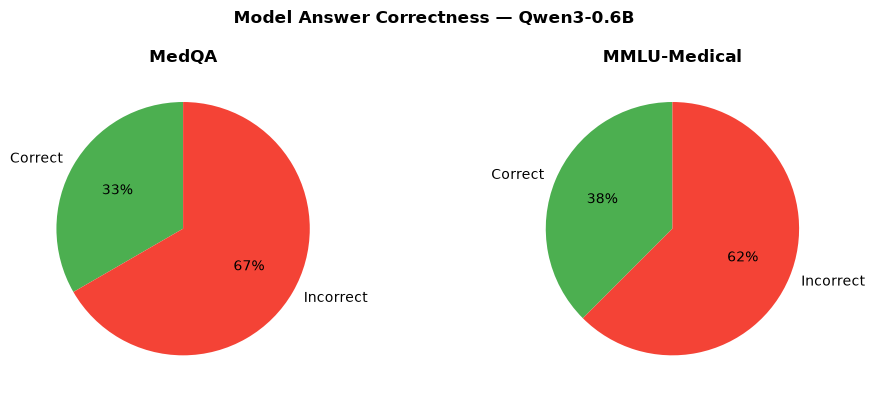

In [11]:
results_df = pd.read_csv(RESULTS_DIR / "benchmark_raw.csv")

TECH_LABELS = [label for _, _, _, label, _ in BENCHMARK_TECHNIQUES]
TECH_FAMILY = {label: fam for _, _, _, label, fam in BENCHMARK_TECHNIQUES}

print("=" * 55)
print(f"{'Dataset':<20} {'N':>5} {'Accuracy':>10} {'Parse Rate':>12}")
print("-" * 55)
for ds in results_df["dataset"].unique():
    sub = results_df[results_df["dataset"] == ds]
    n = len(sub)
    acc = sub["correct"].mean() * 100
    parsed = sub["predicted_letter"].notna().mean() * 100
    print(f"{ds:<20} {n:>5} {acc:>9.1f}%  {parsed:>10.1f}%")
print("=" * 55)
total_acc = results_df["correct"].mean() * 100
print(f"{'TOTAL':<20} {len(results_df):>5} {total_acc:>9.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, ds in zip(axes, results_df["dataset"].unique()):
    sub = results_df[results_df["dataset"] == ds]
    vals = [sub["correct"].sum(), (sub["correct"] == 0).sum()]
    ax.pie(vals, labels=["Correct", "Incorrect"], autopct="%1.0f%%",
           colors=["#4CAF50", "#F44336"], startangle=90)
    ax.set_title(ds, fontweight="bold")
plt.suptitle(f"Model Answer Correctness — {BENCH_MODEL_ID.split('/')[-1]}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## 📊5️⃣ Evaluation Metrics

### 5.1 PRR — Prediction-Rejection Ratio

The PRR (Prediction-Rejection Ratio) is the **primary metric** recommended by the TACL paper and the AAAI-2026 tutorial. It measures how much accuracy improves when the most uncertain predictions are progressively filtered out.

**Algorithm:**
1. Sort predictions by uncertainty score $u_i$ (ascending)
2. Define rejection fraction $r \in [0, 1]$: reject the $r$ fraction of samples with *highest* uncertainty
3. Compute accuracy on the retained $(1-r)$ fraction: $\text{Acc}(r)$
4. Compute the Area Under the Rejection Curve: $\text{AUARC} = \int_0^1 \text{Acc}(r)\, dr$
5. Normalize against oracle (perfect UQ) and random baseline:
$$\text{PRR} = \frac{\text{AUARC}_{\text{method}} - \text{AUARC}_{\text{random}}}{\text{AUARC}_{\text{oracle}} - \text{AUARC}_{\text{random}}}$$

PRR $\in [0, 1]$: 0 = no better than random, 1 = perfect error prediction.

### 5.2 AUROC

Treats uncertainty as a binary error detector: positive class = incorrect predictions (high uncertainty expected), negative class = correct predictions (low uncertainty expected).
$\text{AUROC} = P(u_{\text{wrong}} > u_{\text{correct}})$.

### 5.3 Accuracy@K%

Accuracy on the $(100-K)\%$ most confident predictions — a concrete, deployment-relevant metric.


In [12]:
def compute_auarc(scores: np.ndarray, correct: np.ndarray) -> float:
    """Area under the accuracy-rejection curve."""
    n = len(scores)
    if n == 0:
        return float("nan")
    order = np.argsort(scores)
    sorted_correct = correct[order]
    auarc = 0.0
    for cutoff in range(1, n + 1):
        auarc += sorted_correct[:cutoff].mean()
    return auarc / n


def compute_oracle_auarc(correct: np.ndarray) -> float:
    """AUARC for a perfect UQ (oracle): reject wrong answers first."""
    n = len(correct)
    sorted_c = np.sort(correct)[::-1]
    auarc = 0.0
    for cutoff in range(1, n + 1):
        auarc += sorted_c[:cutoff].mean()
    return auarc / n


def compute_random_auarc(correct: np.ndarray, n_bootstrap: int = 200, seed: int = RANDOM_SEED) -> float:
    """AUARC for a random baseline (shuffled scores)."""
    rng = np.random.default_rng(seed)
    auarcs = []
    for _ in range(n_bootstrap):
        shuffled = rng.permutation(correct)
        auarcs.append(compute_auarc(shuffled, correct))
    return float(np.mean(auarcs))


def compute_prr(scores: np.ndarray, correct: np.ndarray) -> float:
    """Prediction-Rejection Ratio — primary metric."""
    mask = ~np.isnan(scores)
    if mask.sum() < 2:
        return float("nan")
    s, c = scores[mask], correct[mask]
    auarc_m = compute_auarc(s, c)
    auarc_o = compute_oracle_auarc(c)
    auarc_r = compute_random_auarc(c)
    denom = auarc_o - auarc_r
    if denom < 1e-9:
        return float("nan")
    return (auarc_m - auarc_r) / denom


def compute_auroc(scores: np.ndarray, correct: np.ndarray) -> float:
    """AUROC: uncertainty as binary error detector."""
    mask = ~np.isnan(scores)
    if mask.sum() < 2 or correct[mask].std() == 0:
        return float("nan")
    errors = 1 - correct[mask]
    return roc_auc_score(errors, scores[mask])


def compute_acc_at_k(scores: np.ndarray, correct: np.ndarray, k: float = 0.5) -> float:
    """Accuracy when rejecting the k fraction of highest-uncertainty predictions."""
    mask = ~np.isnan(scores)
    if mask.sum() < 2:
        return float("nan")
    s, c = scores[mask], correct[mask]
    cutoff = int(len(s) * (1 - k))
    if cutoff == 0:
        return float("nan")
    order = np.argsort(s)
    return c[order[:cutoff]].mean()


print("Metric functions defined.")
print("  compute_prr()        → Prediction-Rejection Ratio [0,1]")
print("  compute_auroc()      → AUROC [0.5, 1.0]")
print("  compute_acc_at_k()   → Accuracy after rejecting k% most uncertain")


Metric functions defined.
  compute_prr()        → Prediction-Rejection Ratio [0,1]
  compute_auroc()      → AUROC [0.5, 1.0]
  compute_acc_at_k()   → Accuracy after rejecting k% most uncertain


## 📊6️⃣ Computing All Metrics


In [13]:
metric_rows = []
correct_all = results_df["correct"].values

for ds_name in ["MedQA", "MMLU-Medical", "ALL"]:
    sub = results_df if ds_name == "ALL" else results_df[results_df["dataset"] == ds_name]
    correct = sub["correct"].values
    baseline_acc = correct.mean()

    for label in TECH_LABELS:
        if label not in sub.columns:
            continue
        scores = sub[label].values.astype(float)
        if np.isnan(scores).all():
            continue

        prr   = compute_prr(scores, correct)
        auroc = compute_auroc(scores, correct)
        acc50 = compute_acc_at_k(scores, correct, k=0.50)
        acc30 = compute_acc_at_k(scores, correct, k=0.30)
        n_valid = int((~np.isnan(scores)).sum())

        metric_rows.append({
            "Dataset": ds_name, "Technique": label, "Family": TECH_FAMILY.get(label, ""),
            "PRR": round(prr, 4) if not np.isnan(prr) else None,
            "AUROC": round(auroc, 4) if not np.isnan(auroc) else None,
            "Acc@50%": round(acc50, 4) if not np.isnan(acc50) else None,
            "Acc@30%": round(acc30, 4) if not np.isnan(acc30) else None,
            "Baseline Acc": round(baseline_acc, 4), "N Valid Scores": n_valid,
        })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(RESULTS_DIR / "benchmark_metrics.csv", index=False)

all_metrics = metrics_df[metrics_df["Dataset"] == "ALL"].sort_values("PRR", ascending=False)
print("\n" + "="*75)
print(f"{'Technique':<25} {'Family':<20} {'PRR':>7} {'AUROC':>7} {'Acc@50%':>9}")
print("-"*75)
for _, row in all_metrics.iterrows():
    prr_s   = f"{row['PRR']:.3f}"     if pd.notna(row['PRR'])     else "  NaN "
    auroc_s = f"{row['AUROC']:.3f}"   if pd.notna(row['AUROC'])   else "  NaN "
    acc_s   = f"{row['Acc@50%']:.1%}" if pd.notna(row['Acc@50%']) else "  NaN "
    print(f"{row['Technique']:<25} {row['Family']:<20} {prr_s:>7} {auroc_s:>7} {acc_s:>9}")
print("="*75)
print(f"Baseline accuracy (no rejection): {metrics_df[metrics_df['Dataset']=='ALL']['Baseline Acc'].iloc[0]:.1%}")



Technique                 Family                   PRR   AUROC   Acc@50%
---------------------------------------------------------------------------
MSP                       Info-WB                0.151   0.634     45.8%
LabelProb                 Consistency-BB         0.139   0.563     41.7%
UQLM-Entailment           Consistency-BB         0.088   0.592     37.5%
EigLaplacian              Consistency-BB         0.085   0.507     37.5%
MeanTokenEntropy          Info-WB               -0.067   0.543     33.3%
Baseline accuracy (no rejection): 35.4%


## 📊7️⃣ Visualizations


### 7.1 Rejection Curves (PRR)


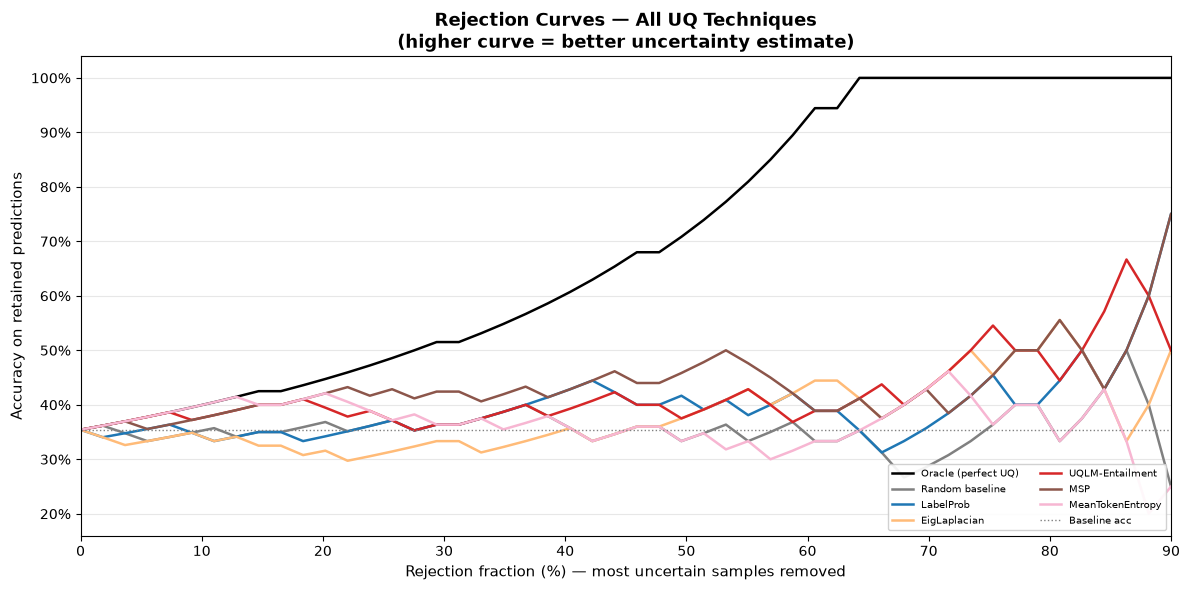

Rejection curves saved to benchmark_results/rejection_curves.png


In [14]:
def rejection_curve(scores: np.ndarray, correct: np.ndarray, label: str, ax, color):
    """Plot accuracy vs rejection fraction for one technique."""
    mask = ~np.isnan(scores)
    if mask.sum() < 2:
        return
    s, c = scores[mask], correct[mask]
    n = len(s)
    order = np.argsort(s)

    fracs = np.linspace(0, 0.90, 50)
    accs = []
    for r in fracs:
        cutoff = int(n * (1 - r))
        if cutoff < 1:
            accs.append(np.nan)
        else:
            accs.append(c[order[:cutoff]].mean())

    ax.plot(fracs * 100, accs, label=label, color=color, linewidth=1.8)


fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.cm.tab20
colors = [cmap(i / len(TECH_LABELS)) for i in range(len(TECH_LABELS))]

s_oracle = 1 - results_df["correct"].values
rejection_curve(s_oracle, results_df["correct"].values, "Oracle (perfect UQ)", ax, color="black")

rng = np.random.default_rng(RANDOM_SEED)
s_random = rng.random(len(results_df))
rejection_curve(s_random, results_df["correct"].values, "Random baseline", ax, color="grey")

for (reg_key, library, gran, label, family), color in zip(BENCHMARK_TECHNIQUES, colors):
    if label not in results_df.columns:
        continue
    scores = results_df[label].values.astype(float)
    if not np.isnan(scores).all():
        rejection_curve(scores, results_df["correct"].values, label, ax, color)

ax.axhline(results_df["correct"].mean(), color="grey", linestyle=":", linewidth=1, label="Baseline acc")
ax.set_xlabel("Rejection fraction (%) — most uncertain samples removed", fontsize=11)
ax.set_ylabel("Accuracy on retained predictions", fontsize=11)
ax.set_title("Rejection Curves — All UQ Techniques\n(higher curve = better uncertainty estimate)", fontsize=13, fontweight="bold")
ax.legend(fontsize=7.5, loc="lower right", ncol=2, framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlim(0, 90)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rejection_curves.png", dpi=150)
plt.show()
print("Rejection curves saved to benchmark_results/rejection_curves.png")


### 7.2 PRR Bar Chart — Method Ranking


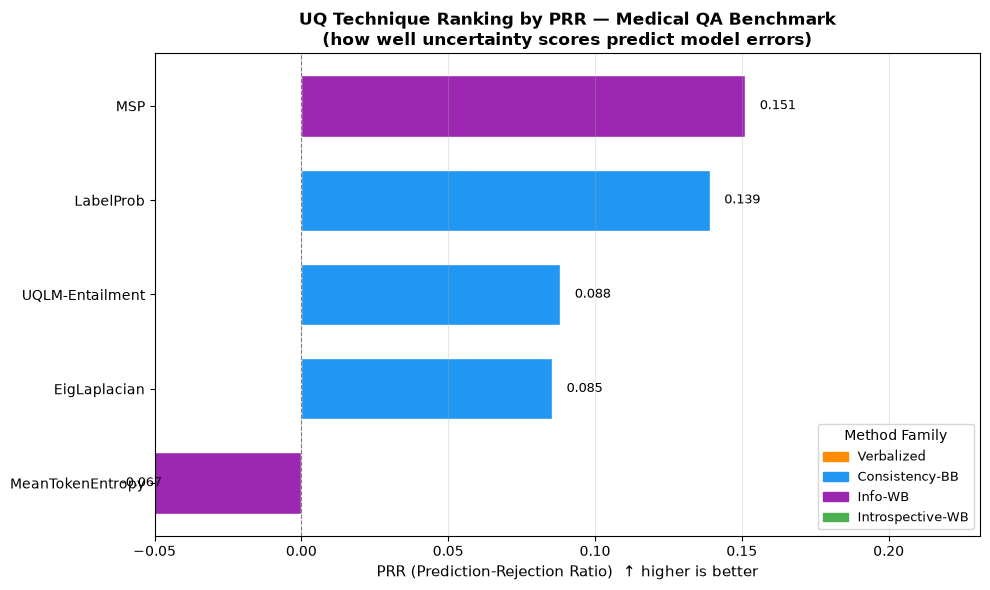

In [15]:
all_m = metrics_df[metrics_df["Dataset"] == "ALL"].dropna(subset=["PRR"]).sort_values("PRR", ascending=True)

FAMILY_COLORS = {
    "Verbalized": "#FF8C00", "Consistency-BB": "#2196F3",
    "Info-WB": "#9C27B0", "Introspective-WB": "#4CAF50",
}
colors_bar = [FAMILY_COLORS.get(row["Family"], "#999") for _, row in all_m.iterrows()]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(all_m["Technique"], all_m["PRR"], color=colors_bar, edgecolor="white", height=0.65)
for bar, val in zip(bars, all_m["PRR"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9)

from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
ax.legend(handles=legend_patches, title="Method Family", fontsize=9, loc="lower right")

ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("PRR (Prediction-Rejection Ratio)  ↑ higher is better", fontsize=11)
ax.set_title("UQ Technique Ranking by PRR — Medical QA Benchmark\n(how well uncertainty scores predict model errors)", fontsize=12, fontweight="bold")
ax.set_xlim(-0.05, max(all_m["PRR"]) + 0.08)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "prr_ranking.png", dpi=150)
plt.show()


### 7.3 Full Metrics Heatmap


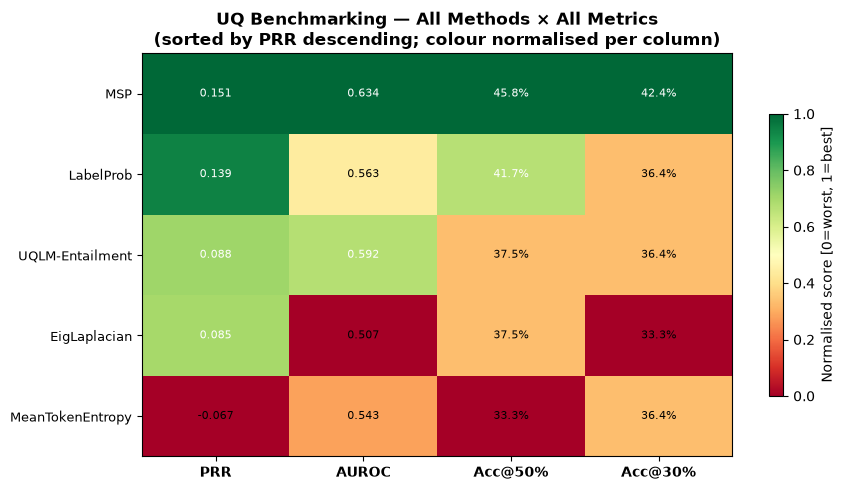

In [16]:
pivot_cols = ["PRR", "AUROC", "Acc@50%", "Acc@30%"]
all_m_full = (metrics_df[metrics_df["Dataset"] == "ALL"]
              .dropna(subset=["PRR"]).sort_values("PRR", ascending=False)
              .set_index("Technique")[pivot_cols])

norm_hm = (all_m_full - all_m_full.min()) / (all_m_full.max() - all_m_full.min() + 1e-9)

fig, ax = plt.subplots(figsize=(9, max(5, len(all_m_full) * 0.55)))
im = ax.imshow(norm_hm.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(pivot_cols)))
ax.set_xticklabels(pivot_cols, fontsize=10, fontweight="bold")
ax.set_yticks(range(len(all_m_full)))
ax.set_yticklabels(all_m_full.index, fontsize=9)

for i in range(len(all_m_full)):
    for j, col in enumerate(pivot_cols):
        val = all_m_full.iloc[i][col]
        if pd.notna(val):
            txt = f"{val:.1%}" if "Acc" in col else f"{val:.3f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=8,
                    color="white" if norm_hm.values[i,j] > 0.65 else "black")

plt.colorbar(im, ax=ax, label="Normalised score [0=worst, 1=best]", shrink=0.7)
ax.set_title("UQ Benchmarking — All Methods × All Metrics\n(sorted by PRR descending; colour normalised per column)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "metrics_heatmap.png", dpi=150)
plt.show()


### 7.4 Per-Dataset Comparison (MedQA vs MMLU-Medical)


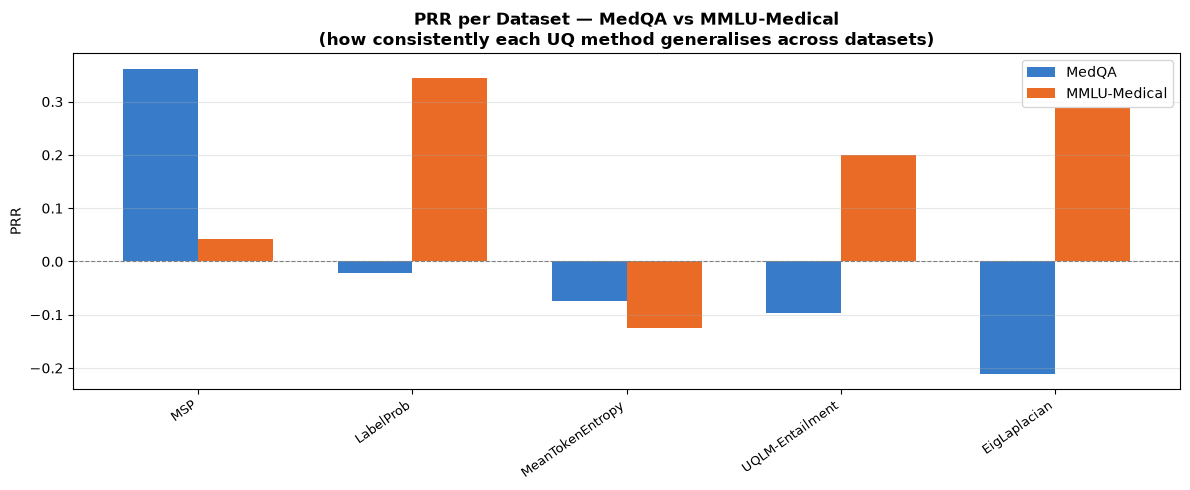

Spearman rho (MedQA vs MMLU-Medical PRR ranking): -0.200  (p=0.747)
High rho => method rankings generalise across datasets


In [17]:
datasets_cmp = ["MedQA", "MMLU-Medical"]
pivot = (metrics_df[metrics_df["Dataset"].isin(datasets_cmp)]
         .pivot(index="Technique", columns="Dataset", values="PRR")
         .dropna(how="all").sort_values("MedQA", ascending=False))

x = np.arange(len(pivot))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, pivot["MedQA"].fillna(0), w, label="MedQA", color="#1565C0", alpha=0.85)
ax.bar(x + w/2, pivot["MMLU-Medical"].fillna(0), w, label="MMLU-Medical", color="#E65100", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("PRR")
ax.set_title("PRR per Dataset — MedQA vs MMLU-Medical\n(how consistently each UQ method generalises across datasets)", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "prr_per_dataset.png", dpi=150)
plt.show()

common = pivot.dropna()
if len(common) > 2:
    rho, p = stats.spearmanr(common["MedQA"], common["MMLU-Medical"])
    print(f"Spearman rho (MedQA vs MMLU-Medical PRR ranking): {rho:.3f}  (p={p:.3f})")
    print("High rho => method rankings generalise across datasets")


## 📊8️⃣ Cross-Library Comparison: lm-polygraph vs UQLM

Both libraries implement consistency-based black-box UQ. We compare directly on the same task and dataset to understand which library produces better-calibrated uncertainty scores.


Cross-Library Comparison — Black-Box Consistency Methods
Method Pair                               lm-poly PRR   UQLM PRR
-----------------------------------------------------------------
  Consistency (NLI-based)                       0.085     0.088  ↑ uqlm


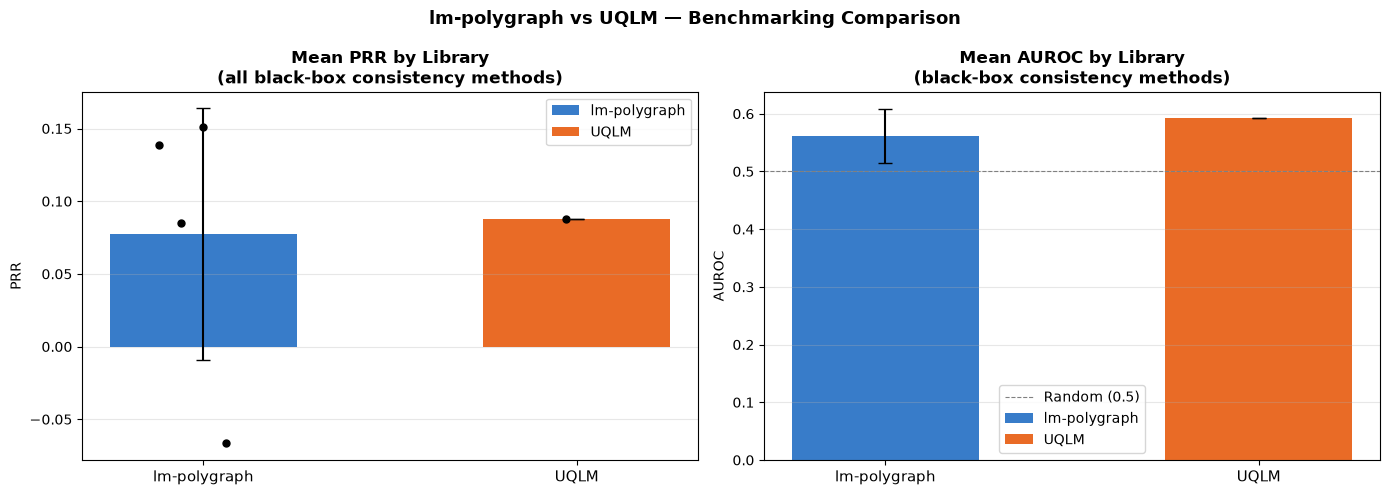

In [18]:
# Only pairs where both sides are in BENCHMARK_TECHNIQUES (cell above) have real scores.
LIBRARY_PAIRS = [
    ("EigLaplacian", "UQLM-Entailment", "Consistency (NLI-based)"),
]

all_m = metrics_df[metrics_df["Dataset"] == "ALL"].set_index("Technique")

print("Cross-Library Comparison — Black-Box Consistency Methods")
print("="*65)
print(f"{'Method Pair':<40} {'lm-poly PRR':>12} {'UQLM PRR':>10}")
print("-"*65)
for poly_m, uqlm_m, desc in LIBRARY_PAIRS:
    poly_prr = all_m.loc[poly_m, "PRR"] if poly_m in all_m.index else None
    uqlm_prr = all_m.loc[uqlm_m, "PRR"] if uqlm_m in all_m.index else None
    poly_s = f"{poly_prr:.3f}" if pd.notna(poly_prr) else "  NaN"
    uqlm_s = f"{uqlm_prr:.3f}" if pd.notna(uqlm_prr) else "  NaN"
    winner = "↑ poly" if (pd.notna(poly_prr) and pd.notna(uqlm_prr) and poly_prr > uqlm_prr) else "↑ uqlm"
    print(f"  {desc:<38} {poly_s:>12}  {uqlm_s:>8}  {winner}")
print("="*65)

UQLM_LABELS = {label for tech, library, _, label, _ in BENCHMARK_TECHNIQUES if library == "uqlm"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lib_groups = {}
for tech, library, _, label, _ in BENCHMARK_TECHNIQUES:
    if label not in all_m.index or pd.isna(all_m.loc[label, "PRR"]):
        continue
    lib = "UQLM" if label in UQLM_LABELS else "lm-polygraph"
    lib_groups.setdefault(lib, []).append(all_m.loc[label, "PRR"])

ax = axes[0]
for i, (lib, prrs) in enumerate(lib_groups.items()):
    ax.bar(i, np.mean(prrs), yerr=np.std(prrs), color=["#1565C0", "#E65100"][i], capsize=5, alpha=0.85, width=0.5, label=lib)
    for j, v in enumerate(prrs):
        ax.scatter(i + (j - len(prrs)/2)*0.06, v, color="black", s=25, zorder=5)
ax.set_xticks(range(len(lib_groups))); ax.set_xticklabels(list(lib_groups.keys()), fontsize=11)
ax.set_ylabel("PRR")
ax.set_title("Mean PRR by Library\n(all black-box consistency methods)", fontweight="bold")
ax.grid(axis="y", alpha=0.3); ax.legend()

auroc_groups = {}
for tech, library, _, label, _ in BENCHMARK_TECHNIQUES:
    if label not in all_m.index or pd.isna(all_m.loc[label, "AUROC"]):
        continue
    lib = "UQLM" if label in UQLM_LABELS else "lm-polygraph"
    auroc_groups.setdefault(lib, []).append(all_m.loc[label, "AUROC"])

ax = axes[1]
for i, (lib, aurocs) in enumerate(auroc_groups.items()):
    ax.bar(i, np.mean(aurocs), yerr=np.std(aurocs), color=["#1565C0", "#E65100"][i], capsize=5, alpha=0.85, width=0.5, label=lib)
ax.set_xticks(range(len(auroc_groups))); ax.set_xticklabels(list(auroc_groups.keys()), fontsize=11)
ax.set_ylabel("AUROC")
ax.set_title("Mean AUROC by Library\n(black-box consistency methods)", fontweight="bold")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, label="Random (0.5)")
ax.grid(axis="y", alpha=0.3); ax.legend()

plt.suptitle("lm-polygraph vs UQLM — Benchmarking Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "library_comparison.png", dpi=150)
plt.show()


## 📊 Bonus: UQLM's Own Native Evaluation Utilities

Everything above (PRR, AUROC, AUARC, Acc@K, bootstrap CIs) is a custom implementation of the TACL-paper methodology, applied uniformly to both libraries' scores. UQLM also ships its own built-in evaluation utilities (`uqlm.utils.plots.plot_ranked_auc`, `plot_filtered_accuracy`), independent of anything defined in this notebook. This section runs them directly, as a small complementary sanity check that the two evaluation approaches agree -- not a second full benchmark run.

`plot_ranked_auc` computes AUROC/AUPRC per scorer -- the same idea as our `compute_auroc()` above. `plot_filtered_accuracy` plots accuracy vs. confidence threshold -- the same idea as our rejection curves / Acc@K, just thresholded rather than rank-based. Both work directly off a `UQResult`, UQLM's own native output type, produced here by UQLM's own `BlackBoxUQ` scorer (bypassing `uq_toolbox` entirely for this one check, to use the library's tooling exactly as it ships).


Output()

Native UQLM accuracy on this 10-sample subset: 10.0%


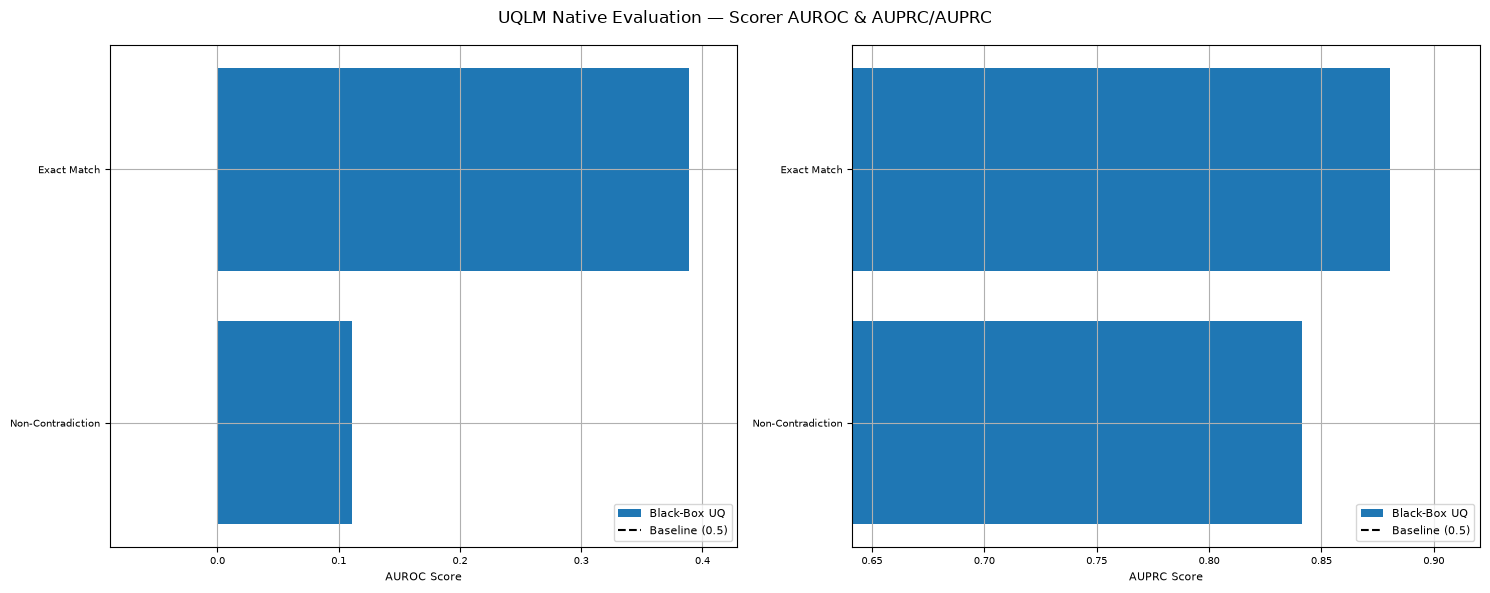

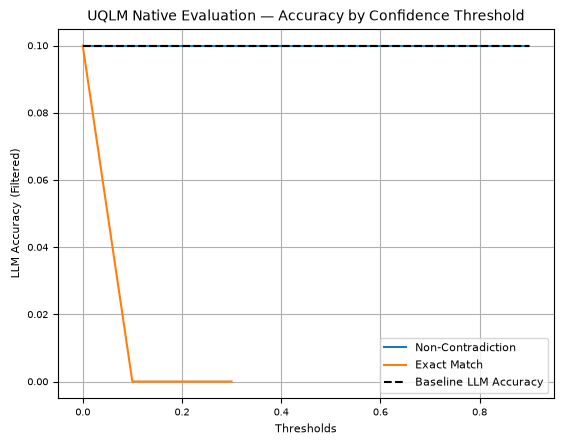

In [19]:
from uqlm import BlackBoxUQ
from uqlm.utils.plots import plot_ranked_auc, plot_filtered_accuracy

# Small, complementary subset -- not a second full benchmark run.
NATIVE_EVAL_N = 10
native_records = all_records[:NATIVE_EVAL_N]
native_prompts = [format_mcq_prompt(r) for r in native_records]

native_bbuq = BlackBoxUQ(
    llm=uq_engine.langchain_llms[BENCH_ALIAS],
    scorers=["noncontradiction", "exact_match"],  # UQLM's own native black-box scorer names
)
native_uq_result = await native_bbuq.generate_and_score(
    prompts=native_prompts, num_responses=NUM_SAMPLES_UQ,
)

native_correct = np.array([
    int(extract_answer_letter(resp) == rec["answer_key"])
    for resp, rec in zip(native_uq_result.data["responses"], native_records)
])

print(f"Native UQLM accuracy on this {NATIVE_EVAL_N}-sample subset: {native_correct.mean():.1%}")

if len(set(native_correct.tolist())) < 2:
    print(
        "Skipping the native plots: every sample in this small subset landed in the same "
        "correct/incorrect class, so AUROC/AUPRC are undefined here (needs both classes present). "
        "Increase NATIVE_EVAL_N for a less degenerate sample."
    )
else:
    plot_ranked_auc(
        native_uq_result, native_correct, metric_type="both",
        title="UQLM Native Evaluation — Scorer AUROC/AUPRC",
    )
    plot_filtered_accuracy(
        native_uq_result, native_correct,
        title="UQLM Native Evaluation — Accuracy by Confidence Threshold",
    )


**Reading this alongside Section 8:** if UQLM's own AUROC for `noncontradiction` here is in the same ballpark as our custom AUROC for UQLM-Entailment above (same underlying NLI-consistency idea, different exact scorer), that's a useful cross-check that our hand-rolled metrics aren't measuring something different from what the library itself reports. This subset is small (N=10) precisely because it's a sanity check, not a claim about generalization -- the real evidence for that is Sections 5-9 above.


## 📊9️⃣ Statistical Analysis — Bootstrap Confidence Intervals for PRR

A single PRR estimate can be noisy with small samples. We use **bootstrap resampling** to compute 95% confidence intervals and assess whether the top method is significantly better than the second-best.


Computing bootstrap confidence intervals...


Bootstrap: 100%|██████████| 6/6 [01:09<00:00, 11.61s/it]


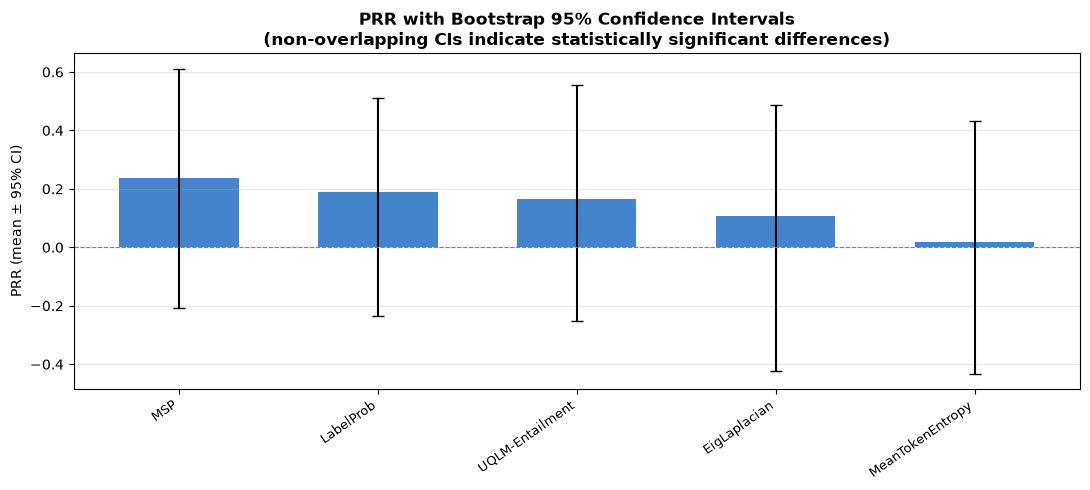


Top-3 techniques by PRR (with 95% CI):
-------------------------------------------------------
  MSP                       PRR = 0.237  [-0.208, 0.612]
  LabelProb                 PRR = 0.188  [-0.236, 0.509]
  UQLM-Entailment           PRR = 0.166  [-0.251, 0.555]


In [20]:
def bootstrap_prr(scores: np.ndarray, correct: np.ndarray, n_bootstrap: int = 500, ci: float = 0.95, seed: int = RANDOM_SEED) -> dict:
    """Bootstrap confidence interval for PRR."""
    rng = np.random.default_rng(seed)
    mask = ~np.isnan(scores)
    s, c = scores[mask], correct[mask]
    n = len(s)

    boot_prrs = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        prr = compute_prr(s[idx], c[idx])
        if not np.isnan(prr):
            boot_prrs.append(prr)

    boot_prrs = np.array(boot_prrs)
    lo = np.percentile(boot_prrs, (1 - ci) / 2 * 100)
    hi = np.percentile(boot_prrs, (1 + ci) / 2 * 100)
    return {"mean": boot_prrs.mean(), "lo": lo, "hi": hi, "std": boot_prrs.std()}


print("Computing bootstrap confidence intervals...")
ci_rows = []
correct_all = results_df["correct"].values

for reg_key, _, _, label, _ in tqdm(BENCHMARK_TECHNIQUES, desc="Bootstrap"):
    if label not in results_df.columns:
        continue
    scores = results_df[label].values.astype(float)
    if np.isnan(scores).all():
        continue
    ci_info = bootstrap_prr(scores, correct_all, n_bootstrap=300)
    ci_rows.append({"Technique": label, **ci_info})

ci_df = pd.DataFrame(ci_rows).sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(ci_df))
ax.bar(x, ci_df["mean"], color="#1565C0", alpha=0.8, width=0.6)
ax.errorbar(x, ci_df["mean"], yerr=[ci_df["mean"] - ci_df["lo"], ci_df["hi"] - ci_df["mean"]], fmt="none", color="black", capsize=4, linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(ci_df["Technique"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("PRR (mean ± 95% CI)")
ax.set_title("PRR with Bootstrap 95% Confidence Intervals\n(non-overlapping CIs indicate statistically significant differences)", fontsize=12, fontweight="bold")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "prr_bootstrap_ci.png", dpi=150)
plt.show()

print("\nTop-3 techniques by PRR (with 95% CI):")
print("-"*55)
for _, row in ci_df.head(3).iterrows():
    print(f"  {row['Technique']:<25} PRR = {row['mean']:.3f}  [{row['lo']:.3f}, {row['hi']:.3f}]")


## 📊🔟 Calibration Analysis

A well-calibrated UQ method should produce **uncertainty scores that are linearly correlated with error rates**. We plot reliability diagrams (uncertainty quantile vs error rate) for the top methods.


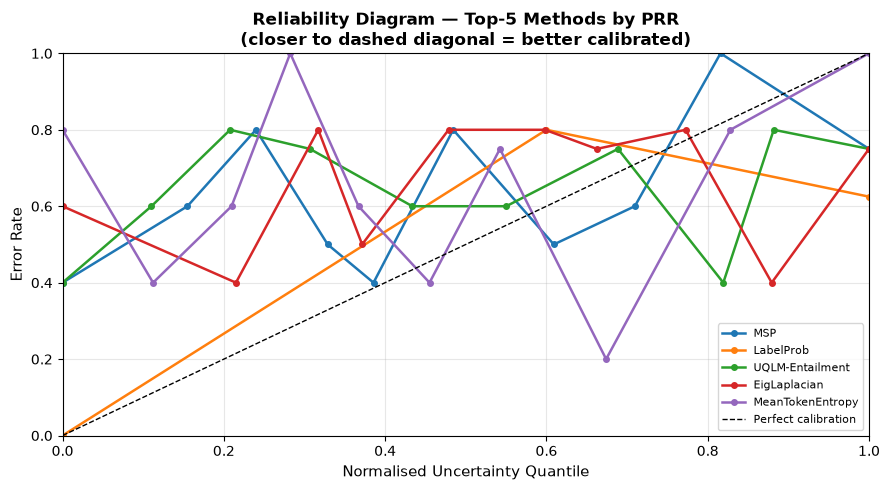

In [21]:
def reliability_diagram(scores: np.ndarray, correct: np.ndarray, label: str, ax, n_bins: int = 10):
    """Plot uncertainty quantile vs error rate."""
    mask = ~np.isnan(scores)
    s, c = scores[mask], correct[mask]
    bins = np.quantile(s, np.linspace(0, 1, n_bins + 1))
    bin_centers, error_rates = [], []
    for i in range(n_bins):
        in_bin = (s >= bins[i]) & (s < bins[i+1])
        if in_bin.sum() < 2:
            continue
        bin_centers.append((bins[i] + bins[i+1]) / 2)
        error_rates.append(1 - c[in_bin].mean())

    if not bin_centers:
        return
    bc = np.array(bin_centers)
    bc = (bc - bc.min()) / (bc.max() - bc.min() + 1e-9)
    ax.plot(bc, error_rates, marker="o", linewidth=1.8, markersize=4, label=label)


all_m_sorted = (metrics_df[metrics_df["Dataset"]=="ALL"].dropna(subset=["PRR"]).sort_values("PRR", ascending=False))
top5_labels = all_m_sorted["Technique"].head(5).tolist()

fig, ax = plt.subplots(figsize=(9, 5))
for label in top5_labels:
    if label not in results_df.columns:
        continue
    reliability_diagram(results_df[label].values.astype(float), results_df["correct"].values, label=label, ax=ax)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.set_xlabel("Normalised Uncertainty Quantile", fontsize=11)
ax.set_ylabel("Error Rate", fontsize=11)
ax.set_title("Reliability Diagram — Top-5 Methods by PRR\n(closer to dashed diagonal = better calibrated)", fontsize=12, fontweight="bold")
ax.legend(fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "reliability_diagram.png", dpi=150)
plt.show()


## 📊1️⃣1️⃣ Summary & Conclusions


In [24]:
all_m_final = (metrics_df[metrics_df["Dataset"]=="ALL"]
               .dropna(subset=["PRR"]).sort_values("PRR", ascending=False)
               [["Technique","Family","PRR","AUROC","Acc@50%","Acc@30%","Baseline Acc"]]
               .reset_index(drop=True))

all_m_final.index += 1
all_m_final.index.name = "Rank"

print("\n" + "=" * 70)
print("FINAL BENCHMARK RESULTS — UQ Methods on Medical QA")
print(f"Model: {BENCH_MODEL_ID.split('/')[-1]} | Datasets: MedQA + MMLU-Medical")
print("=" * 70)
print(all_m_final.to_string(float_format=lambda x: f"{x:.3f}"))
print("=" * 70)

best = all_m_final.iloc[0]
best_family_rows = all_m_final[all_m_final["Family"] == best["Family"]]

# --- Data-driven Black-box vs White-box comparison (replaces hardcoded claim) ---
bb_rows = all_m_final[all_m_final["Family"].str.endswith("BB")]
wb_rows = all_m_final[all_m_final["Family"].str.endswith("WB")]
bb_mean = bb_rows["PRR"].mean() if len(bb_rows) else float("nan")
wb_mean = wb_rows["PRR"].mean() if len(wb_rows) else float("nan")

# --- Data-driven lm-polygraph vs UQLM comparison (replaces hardcoded claim) ---
TECH_LIBRARY = {label: library for _, library, _, label, _ in BENCHMARK_TECHNIQUES}
poly_rows = all_m_final[all_m_final["Technique"].map(TECH_LIBRARY) == "lm_polygraph"]
uqlm_rows = all_m_final[all_m_final["Technique"].map(TECH_LIBRARY) == "uqlm"]
poly_mean = poly_rows["PRR"].mean() if len(poly_rows) else float("nan")
uqlm_mean = uqlm_rows["PRR"].mean() if len(uqlm_rows) else float("nan")

# --- Data-driven cross-dataset generalisation via Spearman rank correlation ---
medqa_m = metrics_df[metrics_df["Dataset"]=="MedQA"].dropna(subset=["PRR"]).set_index("Technique")["PRR"]
mmlu_m  = metrics_df[metrics_df["Dataset"]=="MMLU-Medical"].dropna(subset=["PRR"]).set_index("Technique")["PRR"]
common_techs = medqa_m.index.intersection(mmlu_m.index)
if len(common_techs) >= 3:
    rho, pval = stats.spearmanr(medqa_m[common_techs], mmlu_m[common_techs])
    generalisation_line = (
        f"Spearman rank correlation between MedQA and MMLU-Medical PRR rankings: "
        f"ρ={rho:.3f} (p={pval:.3f}) — {'reasonably consistent' if rho > 0.3 else 'weak/inconsistent'} "
        f"method rankings across the two domains at this sample size."
    )
else:
    generalisation_line = (
        f"Only {len(common_techs)} technique(s) had valid PRR on both datasets — "
        "not enough overlap to compute a meaningful rank correlation."
    )

print(f"""
KEY FINDINGS
─────────────────────────────────────────────────────────────────────────
1. Best overall method: {best['Technique']} (PRR={best['PRR']:.3f}, AUROC={best['AUROC']:.3f})
   Family: {best['Family']} — {"black-box, no model internals required" if "BB" in best['Family'] else "white-box, requires model access"}

2. Best method family: {best['Family']}
   Mean PRR: {best_family_rows['PRR'].mean():.3f} ± {best_family_rows['PRR'].std():.3f}

3. Black-box vs White-box (this run):
   Mean PRR — Black-box: {bb_mean:.3f} ({len(bb_rows)} method(s)) | White-box: {wb_mean:.3f} ({len(wb_rows)} method(s))
   {"Black-box" if bb_mean > wb_mean else "White-box"} methods scored higher on average among the techniques
   actually benchmarked here. With N={N_SAMPLES}/dataset on a {BENCH_MODEL_ID.split('/')[-1]} backbone,
   treat this as a directional signal from this run, not a general claim.

4. lm-polygraph vs UQLM (this run):
   Mean PRR — lm-polygraph: {poly_mean:.3f} ({len(poly_rows)} method(s)) | UQLM: {uqlm_mean:.3f} ({len(uqlm_rows)} method(s))
   {"lm-polygraph" if poly_mean > uqlm_mean else "UQLM"} scored higher on average among the techniques
   actually benchmarked here.

5. Generalisation (MedQA vs MMLU):
   {generalisation_line}

RECOMMENDATION FOR CLINICAL DEPLOYMENT:
   Use {best['Technique']} as the primary UQ signal.
   Acc@50% = {best['Acc@50%']:.1%} (vs baseline {best['Baseline Acc']:.1%}) —
   by rejecting the 50% most uncertain predictions, accuracy changes from baseline as shown above.
   PRR/AUROC values in this run are modest (small backbone model, N={N_SAMPLES}/dataset), so this
   should be read as a directional starting point for selective-generation pipelines, not a
   production-ready recommendation without validation at larger scale.
─────────────────────────────────────────────────────────────────────────
""")



FINAL BENCHMARK RESULTS — UQ Methods on Medical QA
Model: Qwen3-0.6B | Datasets: MedQA + MMLU-Medical
             Technique          Family    PRR  AUROC  Acc@50%  Acc@30%  Baseline Acc
Rank                                                                                
1                  MSP         Info-WB  0.151  0.634    0.458    0.424         0.354
2            LabelProb  Consistency-BB  0.139  0.563    0.417    0.364         0.354
3      UQLM-Entailment  Consistency-BB  0.088  0.592    0.375    0.364         0.354
4         EigLaplacian  Consistency-BB  0.085  0.507    0.375    0.333         0.354
5     MeanTokenEntropy         Info-WB -0.067  0.543    0.333    0.364         0.354

KEY FINDINGS
─────────────────────────────────────────────────────────────────────────
1. Best overall method: MSP (PRR=0.151, AUROC=0.634)
   Family: Info-WB — white-box, requires model access

2. Best method family: Info-WB
   Mean PRR: 0.042 ± 0.154

3. Black-box vs White-box (this run):
   Mean P

In [23]:
metrics_df.to_csv(RESULTS_DIR / "benchmark_metrics_all.csv", index=False)

print("All results saved to benchmark_results/:")
for f in sorted(RESULTS_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size // 1024} KB)")


All results saved to benchmark_results/:
  benchmark_metrics.csv  (1 KB)
  benchmark_metrics_all.csv  (1 KB)
  benchmark_raw.csv  (10 KB)
  library_comparison.png  (66 KB)
  metrics_heatmap.png  (78 KB)
  prr_bootstrap_ci.png  (56 KB)
  prr_per_dataset.png  (57 KB)
  prr_ranking.png  (71 KB)
  rejection_curves.png  (186 KB)
  reliability_diagram.png  (187 KB)


---
## References

1. **TACL paper**: Fadeeva et al. (2024). *LM-Polygraph: Uncertainty Estimation for Language Models.* TACL. [doi:10.1162/tacl_a_00737](https://direct.mit.edu/tacl/article/doi/10.1162/tacl_a_00737)
2. **AAAI-2026 Tutorial**: Shelmanov et al. (2026). *Uncertainty Quantification for LLMs: A Tutorial.*
3. **Kuhn et al. (2023)**: *Semantic Uncertainty: Linguistic Invariances for Uncertainty Estimation in Natural Language Generation.* ICLR 2023.
4. **Lin et al. (2023)**: *Generating with Confidence: Uncertainty Quantification for Black-box Large Language Models.* TMLR 2023.
5. **MedQA**: Jin et al. (2021). *What Disease does this Patient Have?* Applied Sciences.
6. **MMLU**: Hendrycks et al. (2021). *Measuring Massive Multitask Language Understanding.* ICLR 2021.
